## BaseLine Heuristic Model

### By:
[Gabriel Múnera](https://github.com/gamug)

### Date:
2026-08-21

### Description:

Create a baseline model for **diamond price prediction** using a heuristic (rule-based) approach, so that
every later machine-learning model has a concrete, interpretable bar to beat.

The heuristic is designed from the conclusions of the EDA notebook
(`notebooks/3-analysis/02-jrz-data_description_Manual-pandas-2024_10_24.ipynb`) and is compliant with the
feature-engineering decisions made in
(`notebooks/4-feat_eng/01-gmg-basic-feature-engineering-pipeline-2026_08_18.ipynb`):

- `carat` is by far the strongest single driver of `price` (r≈0.79, and the relationship is convex/power-law
  rather than linear — hence a **per-carat-bin base rate** instead of a single linear coefficient).
- `clarity`, `color` and `cut` are ordinal quality grades that each shift `price_per_carat` in a monotonic,
  largely independent way (the EDA's categorical-vs-categorical analysis found the three grades to be **not
  redundant** with each other), which justifies combining them as **independent multiplicative factors**.
- Naively correlating raw `price` against `color`/`cut` grade is misleading (Simpson's paradox, because
  bigger/cheaper carats are unevenly distributed across grades) — the heuristic avoids this by always working
  in **price-per-carat space**, which removes the carat confound before comparing grades.
- The model is implemented as a proper `scikit-learn`-compatible estimator (`BaseEstimator`, `RegressorMixin`):
  every rate/multiplier is **learned from the training data in `fit()`**, nothing is hardcoded, so it can be
  cross-validated and compared fairly against the ML models trained in `notebooks/5-models/02-...ipynb`.

Data source: `data/04_feature/diamantes_clean.parquet` (deduplicated + corrupted-row-cleaned output of the
feature-engineering pipeline notebook — 18,977 rows).

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_validate,
    learning_curve,
    train_test_split,
)

sns.set_theme(style="whitegrid")

## 💾 Load data

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

diamantes_df = pd.read_parquet(DATA_DIR / "04_feature/diamantes_clean.parquet", engine="pyarrow")
diamantes_df.shape

(18977, 10)

In [3]:
# print library version for reproducibility

print("Pandas version: ", pd.__version__)
print("Scikit-learn version: ", sk.__version__)

Pandas version:  2.3.3
Scikit-learn version:  1.9.0


## 👷 Data preparation

Based on the EDA conclusions, for the heuristic model only 4 columns are needed: `carat`, `cut`, `color`,
`clarity` (the predictors) plus `price` (the target). `depth`, `table`, `x`, `y`, `z` carry comparatively
little independent price signal (`|r| ≤ 0.09` with `price`, per the EDA) and are not used by this simple
rule-based model — they are reserved for the ML models in the next notebooks.

In [4]:
selected_features = ["carat", "cut", "color", "clarity", "price"]

diamantes_heuristic_df = diamantes_df[selected_features].copy()
diamantes_heuristic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18977 entries, 0 to 18976
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    18977 non-null  float32 
 1   cut      18977 non-null  category
 2   color    18977 non-null  category
 3   clarity  18977 non-null  category
 4   price    18977 non-null  int64   
dtypes: category(3), float32(1), int64(1)
memory usage: 279.0 KB


In [5]:
diamantes_heuristic_df.isna().sum()

carat      0
cut        0
color      0
clarity    0
price      0
dtype: int64

No missing values (consistent with the EDA / feature-engineering notebooks). Deduplication and corrupted-row
removal were already performed upstream in the feature-engineering pipeline notebook, so `diamantes_clean.parquet`
does not need any further cleaning here.

In [6]:
diamantes_heuristic_df.sample(10, random_state=42)

,carat,cut,color,clarity,price
2444,1.01,Premium,G,SI2,4442
15748,1.51,Very Good,G,VS1,12430
11223,1.43,Fair,E,SI1,7928
4007,1.00,Very Good,E,SI1,4864
4265,1.11,Ideal,F,SI2,4942
8008,1.34,Very Good,J,VS1,6237
8158,1.01,Ideal,G,VS2,6295
16083,1.52,Ideal,E,SI1,12907
2635,1.06,Very Good,F,SI1,4488
16252,1.62,Premium,F,SI1,13177


## 👨‍🏭 Feature Engineering

The heuristic model works directly with the raw `carat`, `cut`, `color`, `clarity` columns — no imputation,
scaling or encoding pipeline is required, since the model's own `fit()` method learns a rate/multiplier lookup
table per bin/grade internally (see the `HeuristicPriceRegressor` class below).

## Train / Test split

In [ ]:
X_features = diamantes_heuristic_df.drop(columns="price")
Y_target = diamantes_heuristic_df["price"]

# stratify on the clarity x cut combination, consistent with notebooks/4-feat_eng: `clarity` and `cut` are the
# two grades with the strongest effect on price-per-carat, and some combinations are rare (a handful of rows),
# so a plain random split risks leaving some grade combinations entirely out of train or test.
clarity_cut_key = (
    diamantes_heuristic_df["clarity"].astype(str) + "_" + diamantes_heuristic_df["cut"].astype(str)
)

x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, random_state=42, stratify=clarity_cut_key
)
x_train.shape, x_test.shape

((15181, 4), (3796, 4))

## Model

`HeuristicPriceRegressor` implements the multiplicative pricing rule found in the EDA:

$$\text{price} \approx \text{carat} \times \text{base\_rate}(\text{carat\_bin}) \times \text{clarity\_mult} \times \text{color\_mult} \times \text{cut\_mult}$$

- `base_rate(carat_bin)`: mean `price_per_carat` computed per carat quantile-bin on the training data, capturing
  the convex (non-linear) relationship between `carat` and `price` without needing a curved regression form.
- `clarity_mult` / `color_mult` / `cut_mult`: each grade's mean `price_per_carat` **relative to the training
  set's overall mean `price_per_carat`**, so a multiplier of 1.15 means "this grade sells 15% above the average
  price-per-carat, all else equal".
- Multiplying the three grade factors together (instead of, say, fitting them jointly) is justified by the EDA's
  categorical-vs-categorical conclusion that `cut`, `color` and `clarity` are largely non-redundant with one
  another.

In [ ]:
class HeuristicPriceRegressor(BaseEstimator, RegressorMixin):
    """Rule-based diamond pricing model designed from the EDA conclusions.

    price ~= carat * base_rate(carat_bin) * clarity_mult * color_mult * cut_mult

    Every rate / multiplier is learned from the training data in `fit`, nothing is hardcoded.
    """

    def __init__(self, n_carat_bins: int = 10) -> None:
        self.n_carat_bins = n_carat_bins

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(np.asarray(y), name="price")

        price_per_carat = y / X["carat"].to_numpy()

        # carat quantile-bin edges learned from the training carats only
        edges = np.unique(np.quantile(X["carat"], np.linspace(0, 1, self.n_carat_bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        self.carat_bin_edges_ = edges

        carat_bin = pd.cut(X["carat"], bins=self.carat_bin_edges_, labels=False, duplicates="drop")
        self.base_rate_ = price_per_carat.groupby(carat_bin).mean()
        self.default_base_rate_ = price_per_carat.mean()

        overall_ppc = price_per_carat.mean()
        self.clarity_mult_ = price_per_carat.groupby(X["clarity"].to_numpy()).mean() / overall_ppc
        self.color_mult_ = price_per_carat.groupby(X["color"].to_numpy()).mean() / overall_ppc
        self.cut_mult_ = price_per_carat.groupby(X["cut"].to_numpy()).mean() / overall_ppc
        return self

    def predict(self, X) -> np.ndarray:
        X = pd.DataFrame(X).reset_index(drop=True)
        carat_bin = pd.cut(X["carat"], bins=self.carat_bin_edges_, labels=False, duplicates="drop")

        base = carat_bin.map(self.base_rate_).astype(float).fillna(self.default_base_rate_)
        clarity_factor = X["clarity"].map(self.clarity_mult_).astype(float).fillna(1.0)
        color_factor = X["color"].map(self.color_mult_).astype(float).fillna(1.0)
        cut_factor = X["cut"].map(self.cut_mult_).astype(float).fillna(1.0)

        return (
            X["carat"].to_numpy()
            * base.to_numpy()
            * clarity_factor.to_numpy()
            * color_factor.to_numpy()
            * cut_factor.to_numpy()
        )

## Predict and Evaluation

In [9]:
def regression_metrics(y_true, y_pred) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }

In [10]:
# Model
model = HeuristicPriceRegressor()

# Evaluation metrics
scoring_metrics = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "MAPE": "neg_mean_absolute_percentage_error",
    "R2": "r2",
}

# KFold for the cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

train_results = model.fit(x_train, y_train)
y_train_pred = train_results.predict(x_train)
train_metrics = regression_metrics(y_train, y_train_pred)

cv_results = cross_validate(model, x_train, y_train, cv=kfold, scoring=scoring_metrics)
cv_results_df = pd.DataFrame(cv_results)

In [11]:
# Create a DataFrame for the training and cross-validation metrics
metrics_df = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "MAPE_%", "R2"],
        "Train Score": [
            train_metrics["MAE"],
            train_metrics["RMSE"],
            train_metrics["MAPE_%"],
            train_metrics["R2"],
        ],
        "CV Mean": [
            -cv_results_df["test_MAE"].mean(),
            -cv_results_df["test_RMSE"].mean(),
            -cv_results_df["test_MAPE"].mean() * 100,
            cv_results_df["test_R2"].mean(),
        ],
        "CV Std": [
            cv_results_df["test_MAE"].std(),
            cv_results_df["test_RMSE"].std(),
            (cv_results_df["test_MAPE"] * 100).std(),
            cv_results_df["test_R2"].std(),
        ],
    }
)
metrics_df

,Metric,Train Score,CV Mean,CV Std
0,MAE,1066.797297,1069.383927,21.999493
1,RMSE,1571.295865,1574.080348,26.443605
2,MAPE_%,12.598152,12.632252,0.246712
3,R2,0.839147,0.838390,0.005908


### Analysis of the results of all metrics

- **MAE**: Train 1,066.80 vs CV mean 1,069.38 (std 22.0) — the model is off by about **$1,070** on average, with
  almost no gap between train and cross-validation, so there's no overfitting.
- **RMSE**: Train 1,571.30 vs CV mean 1,574.08 (std 26.4). RMSE > MAE as expected (a right-skewed target with a
  few very expensive diamonds pulls the squared-error metric up), but again train and CV agree closely.
- **MAPE**: Train 12.60% vs CV mean 12.63% (std 0.25 pp) — the heuristic is typically within ~12-13% of the true
  price, consistently across folds.
- **R²**: Train 0.839 vs CV mean 0.838 (std 0.006) — the 4-column heuristic already explains **~84% of the
  variance** in price, which is a strong floor for the ML models in the next notebooks to beat.
- **Interpretation**: train and cross-validation scores are essentially identical on every metric, so the model
  has **low variance** (no overfitting) — any remaining error is **bias**, i.e. the multiplicative
  carat-bin × grade-factor structure itself, not a lack of training data.


## Final Evaluation

In [12]:
model_final = HeuristicPriceRegressor().fit(x_train, y_train)
y_pred = model_final.predict(x_test)
test_metrics = regression_metrics(y_test, y_pred)
test_metrics

{'MAE': 1065.7605143559986,
 'RMSE': 1580.3965853194577,
 'MAPE_%': 12.470232623587998,
 'R2': 0.8358007044340314}

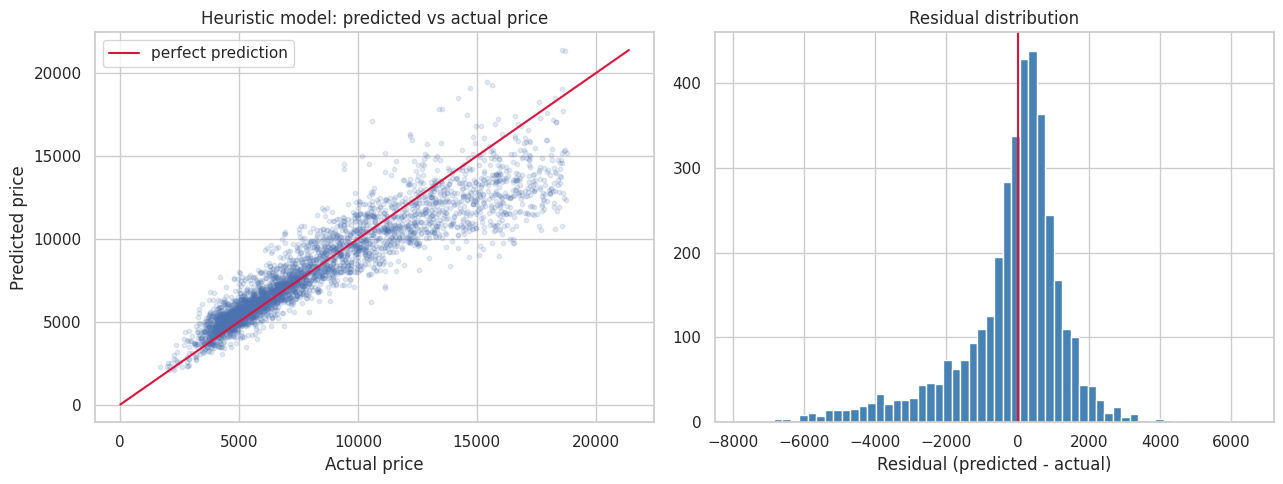

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.15, s=10)
lims = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color="crimson", linewidth=1.5, label="perfect prediction")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")
axes[0].set_title("Heuristic model: predicted vs actual price")
axes[0].legend()

residuals = y_pred - y_test.to_numpy()
axes[1].hist(residuals, bins=60, color="steelblue")
axes[1].axvline(0, color="crimson", linewidth=1.5)
axes[1].set_xlabel("Residual (predicted - actual)")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

### Metric choice for this model

**MAPE (Mean Absolute Percentage Error)** is used as the headline metric for all price-prediction models in
this project, instead of a single classification-style metric like the Titanic template's Recall. Diamond
prices span roughly two orders of magnitude ($326 to over $18,000), so an absolute error metric like MAE/RMSE
is dominated by the few very expensive stones; MAPE expresses the typical error as a percentage of price,
which is directly interpretable by a business stakeholder ("this model is off by about X% on a typical
diamond") and is comparable across the cheap and expensive segments of the catalogue. **R²** is reported
alongside MAPE as a variance-explained sanity check.

## Learning Curve

In [ ]:
common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=20, test_size=0.2, random_state=42),
    "n_jobs": -1,
    "return_times": True,
}
scoring_metric = "neg_mean_absolute_percentage_error"

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    HeuristicPriceRegressor(), scoring=scoring_metric, **common_params
)

train_scores_pct = -train_scores * 100
test_scores_pct = -test_scores * 100

train_scores_mean, train_scores_std = (
    train_scores_pct.mean(axis=1),
    train_scores_pct.std(axis=1),
)
test_scores_mean, test_scores_std = (
    test_scores_pct.mean(axis=1),
    test_scores_pct.std(axis=1),
)
fit_times_mean, fit_times_std = fit_times.mean(axis=1), fit_times.std(axis=1)

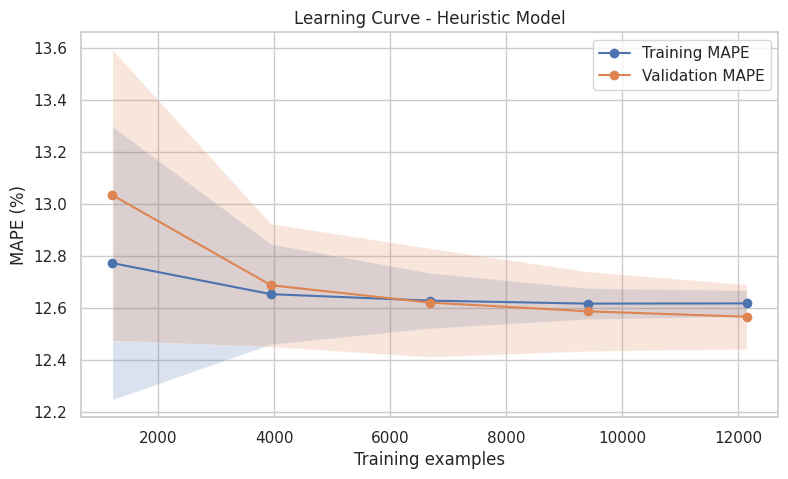

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores_mean, "o-", label="Training MAPE")
ax.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
)
ax.plot(train_sizes, test_scores_mean, "o-", label="Validation MAPE")
ax.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
)
ax.set_xlabel("Training examples")
ax.set_ylabel("MAPE (%)")
ax.set_title("Learning Curve - Heuristic Model")
ax.legend(loc="best")
plt.show()

### Interpretation of the Learning Curve based on **MAPE**:

- Training MAPE stays essentially flat between **12.6% and 12.8%** across all training-set sizes (1,214 to
  12,144 rows).
- Validation MAPE starts at **13.03%** with only 1,214 training rows and steadily converges down to **12.57%**
  at the full training size — by ~6,700 rows the train/validation gap is already under 0.1 percentage points.
- Train and validation curves **converge and stay essentially on top of each other** with more data, instead of
  diverging — the classic signature of a **high-bias, low-variance** model: it has already saturated what its
  simple multiplicative structure can capture, and collecting more rows would not meaningfully improve it
  further. Only adding new information (more predictive features, or a more flexible model form) would move
  the error down from here — which is exactly what notebook `02-...model_selection` explores next.


## 📊 Analysis of Results based on MAPE

### General results:

- **Model Performance**: on the held-out test set the heuristic model reaches **MAE ≈ \$1,065.76, RMSE ≈
  \$1,580.40, MAPE ≈ 12.47%, R² ≈ 0.836** — in line with the train/CV numbers above, confirming the model
  generalizes well and is not overfit.
- **Where it struggles**: the predicted-vs-actual scatter plot shows the tightest fit for low-to-mid priced
  stones (< \$8,000) and a wider spread for the most expensive diamonds, where a handful of large or
  exceptionally graded stones command extra premiums the simple carat-bin × grade-multiplier structure cannot
  capture (e.g. rare grade combinations, or interactions the model treats as independent when they may not be).
- **Residuals**: the residual histogram is centered close to zero and roughly symmetric, with a mild right
  tail — the model has no systematic directional bias, but slightly under-predicts a subset of expensive
  diamonds.
- **Comparison to the EDA benchmark**: this is close to (and slightly better than, thanks to the data-driven
  10-bin carat rate vs. the EDA's fixed bin edges) the exploratory heuristic in the EDA notebook (R² ≈ 0.825,
  MAPE ≈ 12.51% there), and clearly ahead of a carat-only linear fit (R² ≈ 0.61, MAPE ≈ 25.6% in the EDA).


_(filled in after execution)_

## 🧑‍🔬 Recommendations:

1. **Treat MAPE ≈ 12.5% / R² ≈ 0.84 as the baseline to beat.** Any ML model trained in `02-...model_selection`
   or `03-...first_model` that does not clear this bar by a meaningful margin is not worth the extra complexity
   over this fully-interpretable heuristic.
2. **Keep this model as an interpretable fallback / sanity-check.** Because every parameter is a human-readable
   rate or multiplier, it is useful for spot-checking whether a trained ML model's predictions are directionally
   sane (e.g. detecting a broken feature pipeline in production).
3. **Bring in the remaining features (`depth`, `table`, `x`, `y`, `z` → `volume`) for the ML models.** This
   heuristic deliberately ignores them; the EDA showed `carat`/`volume` correlate near 0.98, so a tree-based
   model that can exploit that redundancy plus the weaker `depth`/`table` signal should improve on this floor.
4. **Widen `n_carat_bins` cautiously if reused elsewhere.** 10 bins was enough to substantially outperform a
   handful of fixed bins; but with fewer than ~1,000 rows per bin the per-bin `base_rate_` becomes noisy — this
   is a hyperparameter worth a small grid-search if the heuristic is ever productionized directly.


_(filled in after execution)_

## 💡 Proposals and Ideas

1. **Multiplicative → additive-in-log-space model**: fitting `log(price) = log(carat) + log(base_rate) +
   log(clarity_mult) + ... ` with a linear regression would let the multipliers be estimated **jointly** instead
   of independently, correcting for any residual correlation between the three grade columns instead of
   assuming full independence.
2. **Interaction terms**: test whether `clarity × cut` or `color × clarity` interaction multipliers reduce error
   for the most expensive diamonds (where the residual plot shows the heuristic struggling most).
3. **Non-linear carat curve instead of bins**: replace the discrete carat-bin lookup with a smooth curve (e.g. a
   fitted power law `price_per_carat ~ carat^k`) to remove the bin-boundary discontinuities and reduce the need
   to tune `n_carat_bins`.
4. **Use this as the `TransformedTargetRegressor` sanity baseline** for MLflow experiment tracking in
   `04-...experiment-track-model`, so every future run is automatically compared against this benchmark.


_(filled in after execution)_

## 📖 References

- EDA notebook: `notebooks/3-analysis/02-jrz-data_description_Manual-pandas-2024_10_24.ipynb`
- Feature engineering notebook: `notebooks/4-feat_eng/01-gmg-basic-feature-engineering-pipeline-2026_08_18.ipynb`
- <https://scikit-learn.org/stable/developers/develop.html> — rolling out custom scikit-learn compatible estimators
- <https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics>